In [32]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [33]:
img = cv2.imread("./assets/cameraman.jpeg", 0)
rows, cols = img.shape[:2]

In [34]:
def createLPFilter(shape, center, radius, lpType=2, n=2): 
    rows, cols = shape[:2]
    r, c = np.mgrid[0:rows:1, 0:cols:1] 
    c -= center[0]
    r -= center[1]
    d = np.power(c, 2.0) + np.power(r, 2.0)
    lpFilter_matrix = np.zeros(shape, np.float32) 
    
    if lpType == 0:    # ideal low-pass filter
        lpFilter = np.copy(d)
        lpFilter[lpFilter < pow(radius, 2.0)] = 1
        lpFilter[lpFilter >= pow(radius, 2.0)] = 0
    elif lpType == 1:  # Butterworth low-pass filter
        lpFilter = 1.0 / (1 + np.power(np.sqrt(d)/radius, 2*n)) 
    elif lpType == 2:  # Gaussian low pass filter
        lpFilter = np.exp(-d/(2*pow(radius, 2.0))) 
        
    lpFilter_matrix[:, :, 0] = lpFilter
    lpFilter_matrix[:, :, 1] = lpFilter 
    return lpFilter_matrix

def createHPFilter(shape, center, radius, lpType=2, n=2): 
    rows, cols = shape[:2]
    r, c = np.mgrid[0:rows:1, 0:cols:1] 
    c -= center[0]
    r -= center[1]
    d = np.power(c, 2.0) + np.power(r, 2.0)
    lpFilter_matrix = np.zeros(shape, np.float32) 
    
    if lpType == 0:    # Ideal high pass filter
        lpFilter = np.copy(d)
        lpFilter[lpFilter < pow(radius, 2.0)] = 0
        lpFilter[lpFilter >= pow(radius, 2.0)] = 1 
    elif lpType == 1:  # Butterworth Highpass Filters
        lpFilter = 1.0 - 1.0 / (1 + np.power(np.sqrt(d)/radius, 2*n)) 
    elif lpType == 2:  # Gaussian Highpass Filter
        lpFilter = 1.0 - np.exp(-d/(2*pow(radius, 2.0))) 
        
    lpFilter_matrix[:, :, 0] = lpFilter
    lpFilter_matrix[:, :, 1] = lpFilter 
    return lpFilter_matrix

def stdFftImage(img_gray, rows, cols): 
    fimg = np.copy(img_gray)
    fimg = fimg.astype(np.float32)  
    for r in range(rows):
        for c in range(cols): 
            if (r+c) % 2:
                fimg[r][c] = -1 * fimg[r][c] 
    img_fft = fftImage(fimg, rows, cols)
    return img_fft

def fftImage(img_gray, rows, cols):
    rPadded = cv2.getOptimalDFTSize(rows) 
    cPadded = cv2.getOptimalDFTSize(cols)
    imgPadded = np.zeros((rPadded, cPadded), dtype=np.float32) 
    imgPadded[:rows, :cols] = img_gray
    img_fft = cv2.dft(imgPadded, flags=cv2.DFT_COMPLEX_OUTPUT) 
    return img_fft

def graySpectrum(fft_img):
    real = np.power(fft_img[:, :, 0], 2.0)
    imaginary = np.power(fft_img[:, :, 1], 2.0) 
    amplitude = np.sqrt(real+imaginary)
    spectrum = np.log(amplitude+1.0)
    spectrum = cv2.normalize(spectrum, 0, 1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    spectrum *= 255
    return amplitude, spectrum

In [35]:
image_fft = stdFftImage(img, rows, cols)
amplitude, _ = graySpectrum(image_fft)
minValue, maxValue, minLoc, maxLoc = cv2.minMaxLoc(amplitude)

In [36]:
# 1. Atur Parameter LKP
radius = [10, 20, 30]       # Coba ganti ke 10, 20, atau 30
tipe_filter = [0, 1, 2]   # Coba ganti ke 0 (Ideal), 1 (Butterworth), 2 (Gaussian)


# Percobaan variasi variabel `radius`

Tersimpan: ./assets/radius_10_type_0_lpf_hpf.png


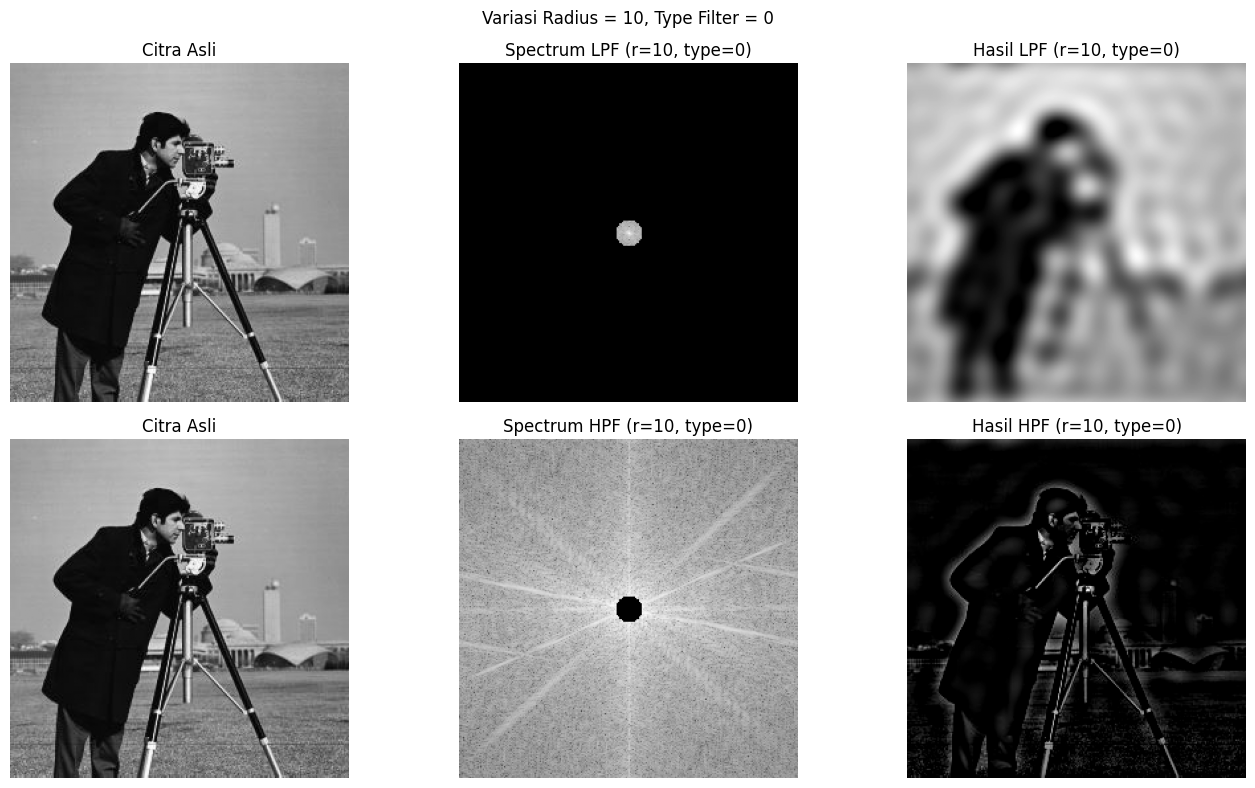

Tersimpan: ./assets/radius_20_type_0_lpf_hpf.png


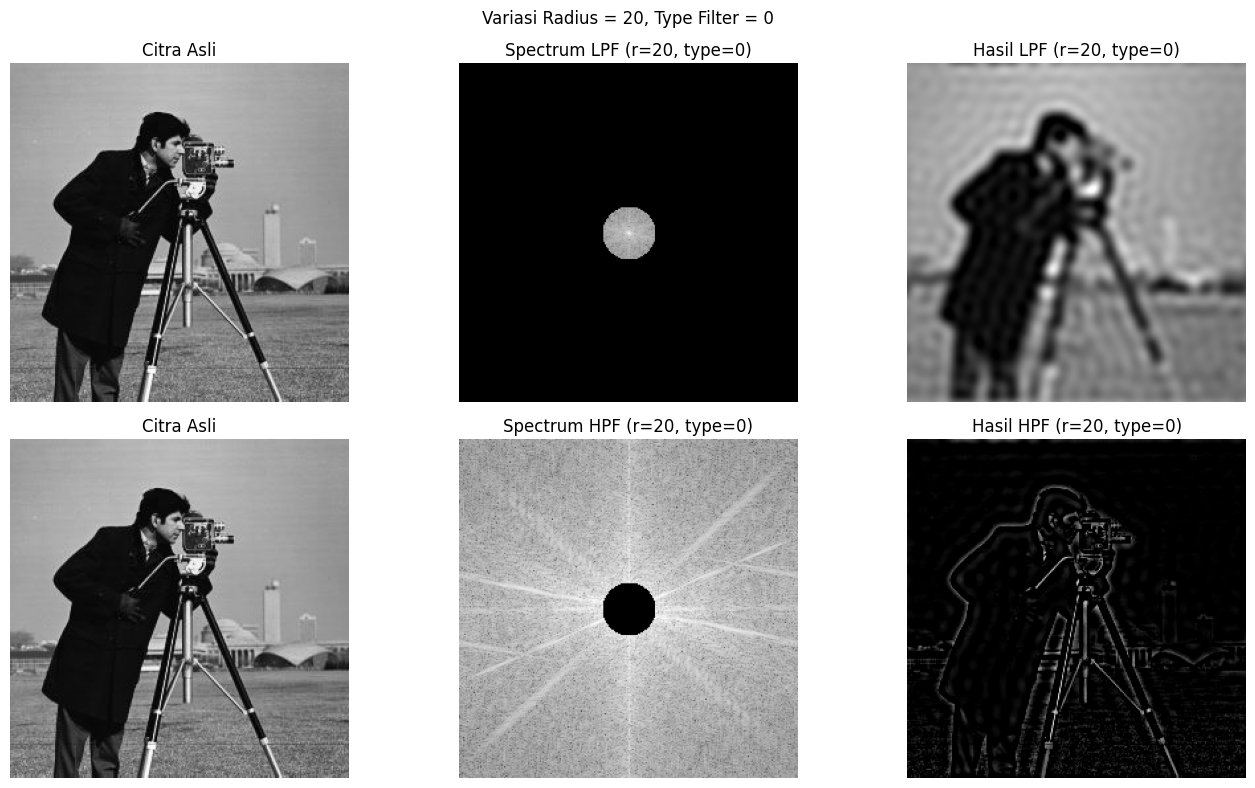

Tersimpan: ./assets/radius_30_type_0_lpf_hpf.png


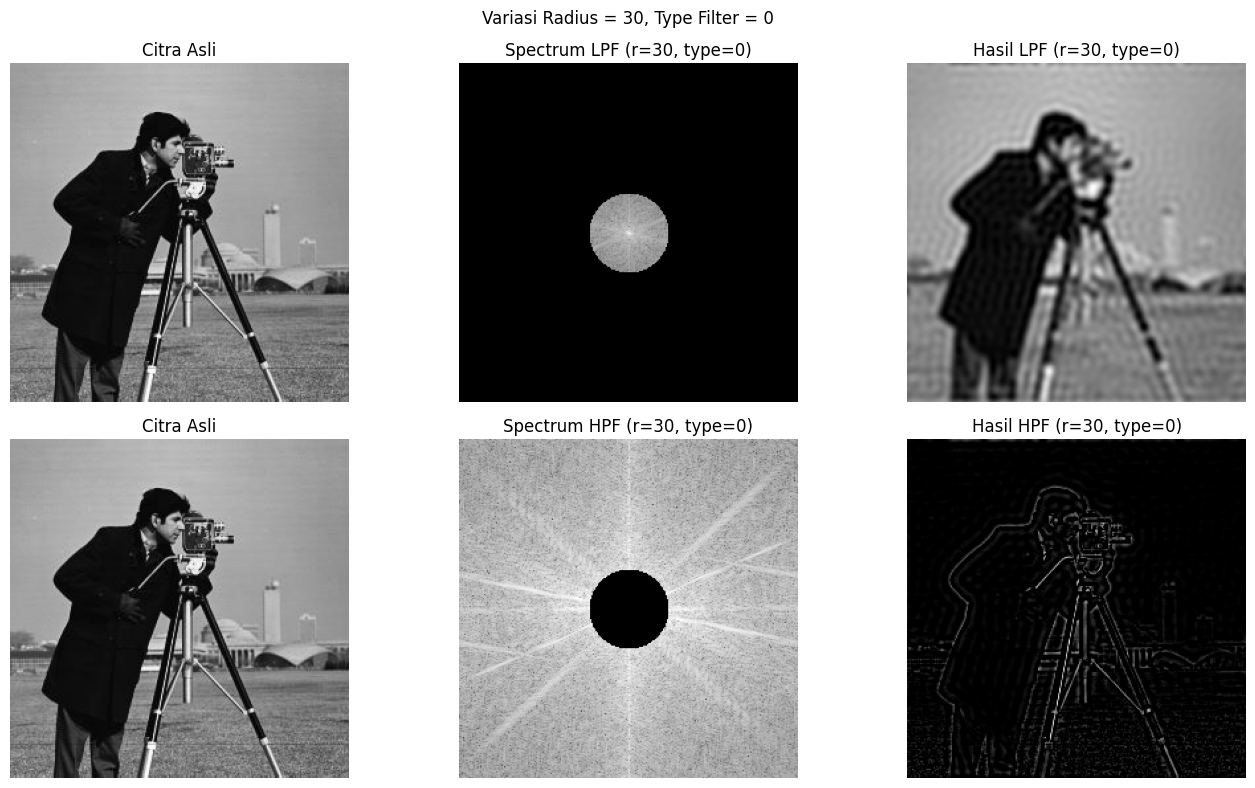

In [37]:
output_dir = "./assets"
os.makedirs(output_dir, exist_ok=True)

for r in radius:
    # Low-pass
    lowPassFilter = createLPFilter(image_fft.shape, maxLoc, r, tipe_filter[0])
    img_lp_filter = lowPassFilter * image_fft
    _, spektrum_lp = graySpectrum(img_lp_filter)

    img_ift_lp = cv2.dft(
        img_lp_filter,
        flags=cv2.DFT_INVERSE + cv2.DFT_REAL_OUTPUT + cv2.DFT_SCALE,
    )
    ori_lp = np.copy(img_ift_lp[:rows, :cols])

    for rr in range(rows):
        for cc in range(cols):
            if (rr + cc) % 2:
                ori_lp[rr][cc] = -1 * ori_lp[rr][cc]

    ori_lp = np.clip(ori_lp, 0, 255).astype(np.uint8)

    # High-pass
    highPassFilter = createHPFilter(image_fft.shape, maxLoc, r, tipe_filter[0])
    img_hp_filter = highPassFilter * image_fft
    _, spektrum_hp = graySpectrum(img_hp_filter)

    img_ift_hp = cv2.dft(
        img_hp_filter,
        flags=cv2.DFT_INVERSE + cv2.DFT_REAL_OUTPUT + cv2.DFT_SCALE,
    )
    ori_hp = np.copy(img_ift_hp[:rows, :cols])

    for rr in range(rows):
        for cc in range(cols):
            if (rr + cc) % 2:
                ori_hp[rr][cc] = -1 * ori_hp[rr][cc]

    ori_hp = np.clip(ori_hp, 0, 255).astype(np.uint8)

    # Tampilkan hasil LPF + HPF untuk radius yang sama
    fig, ax = plt.subplots(2, 3, figsize=(14, 8))

    ax[0, 0].imshow(img, cmap="gray")
    ax[0, 0].set_title("Citra Asli")
    ax[0, 0].axis("off")

    ax[0, 1].imshow(spektrum_lp, cmap="gray")
    ax[0, 1].set_title(f"Spectrum LPF (r={r}, type=0)")
    ax[0, 1].axis("off")

    ax[0, 2].imshow(ori_lp, cmap="gray")
    ax[0, 2].set_title(f"Hasil LPF (r={r}, type=0)")
    ax[0, 2].axis("off")

    ax[1, 0].imshow(img, cmap="gray")
    ax[1, 0].set_title("Citra Asli")
    ax[1, 0].axis("off")

    ax[1, 1].imshow(spektrum_hp, cmap="gray")
    ax[1, 1].set_title(f"Spectrum HPF (r={r}, type=0)")
    ax[1, 1].axis("off")

    ax[1, 2].imshow(ori_hp, cmap="gray")
    ax[1, 2].set_title(f"Hasil HPF (r={r}, type=0)")
    ax[1, 2].axis("off")

    plt.suptitle(f"Variasi Radius = {r}, Type Filter = 0")
    plt.tight_layout()

    file_path = f"{output_dir}/radius_{r}_type_0_lpf_hpf.png"
    fig.savefig(file_path, dpi=200, bbox_inches="tight")
    print(f"Tersimpan: {file_path}")

    plt.show()
    plt.close(fig)

# Percobaan variasi variabel `type` (radius tetap 10)

Tersimpan: ./assets/type_0_radius_10_lpf_hpf.png


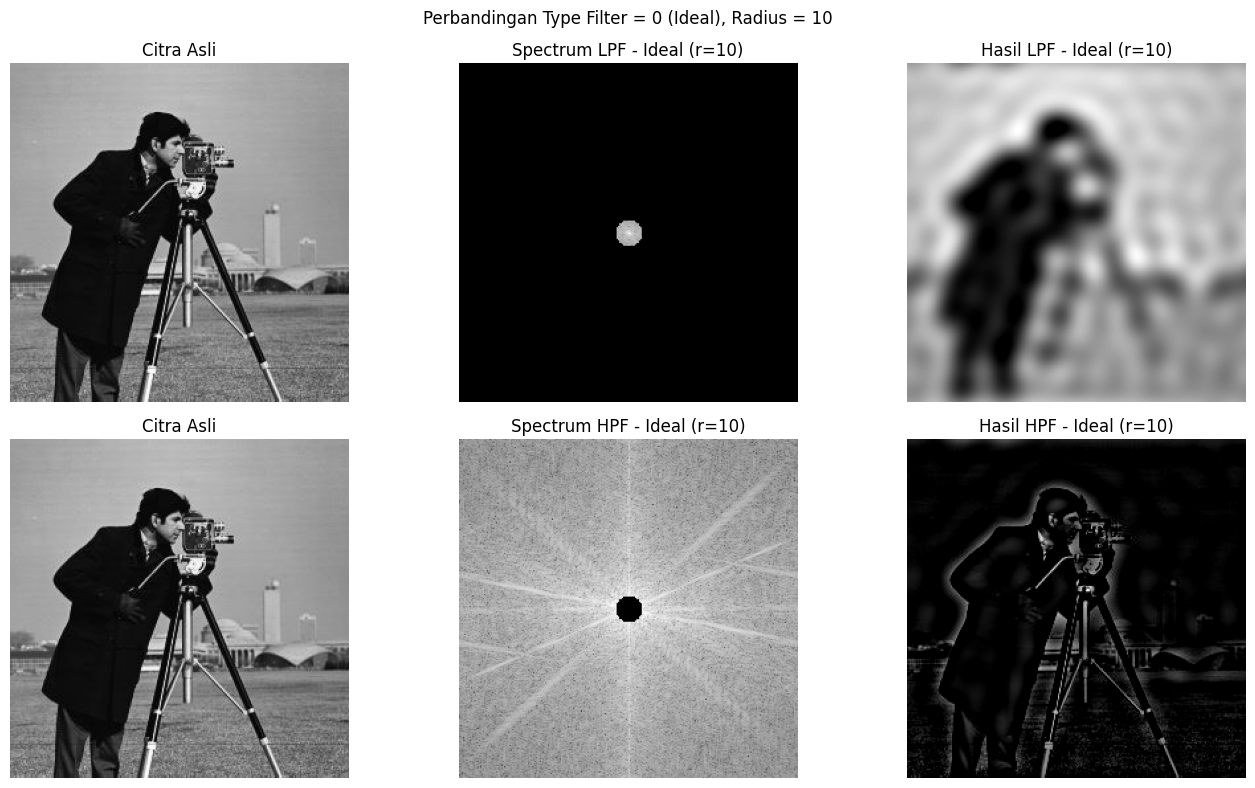

Tersimpan: ./assets/type_1_radius_10_lpf_hpf.png


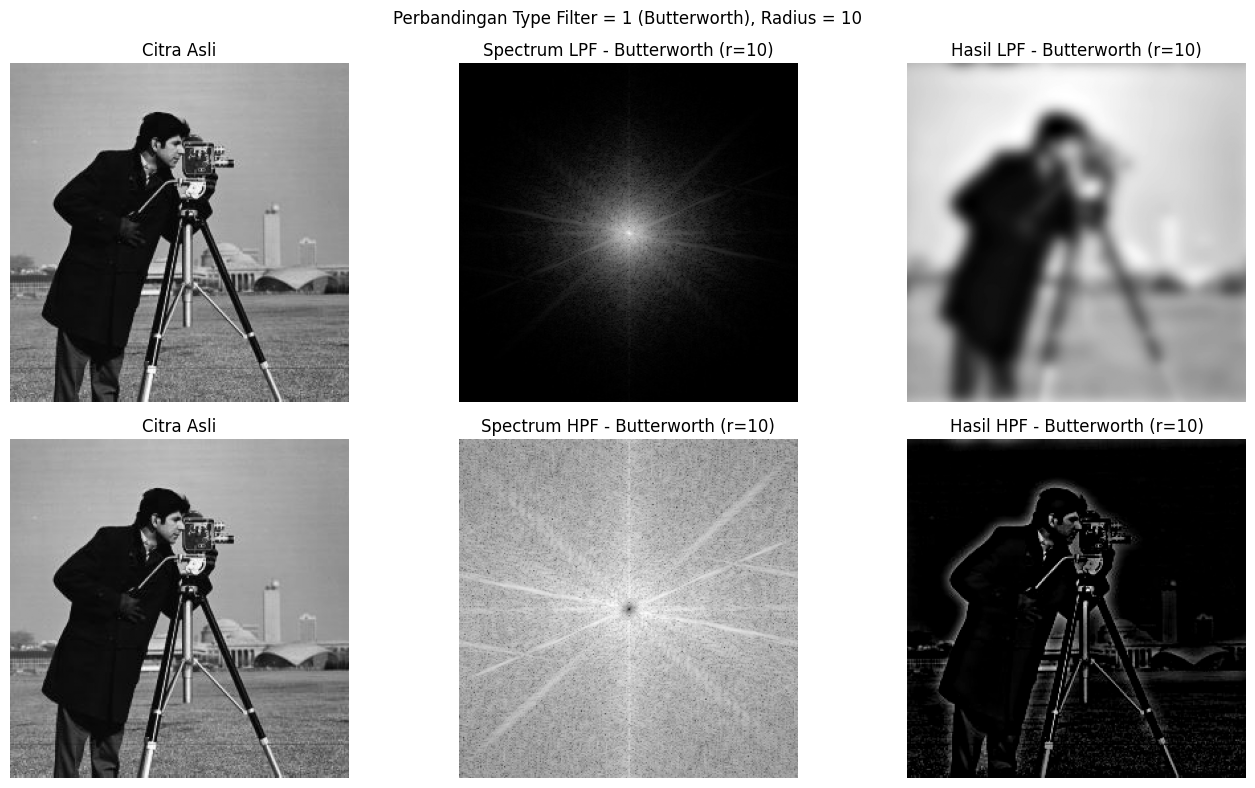

Tersimpan: ./assets/type_2_radius_10_lpf_hpf.png


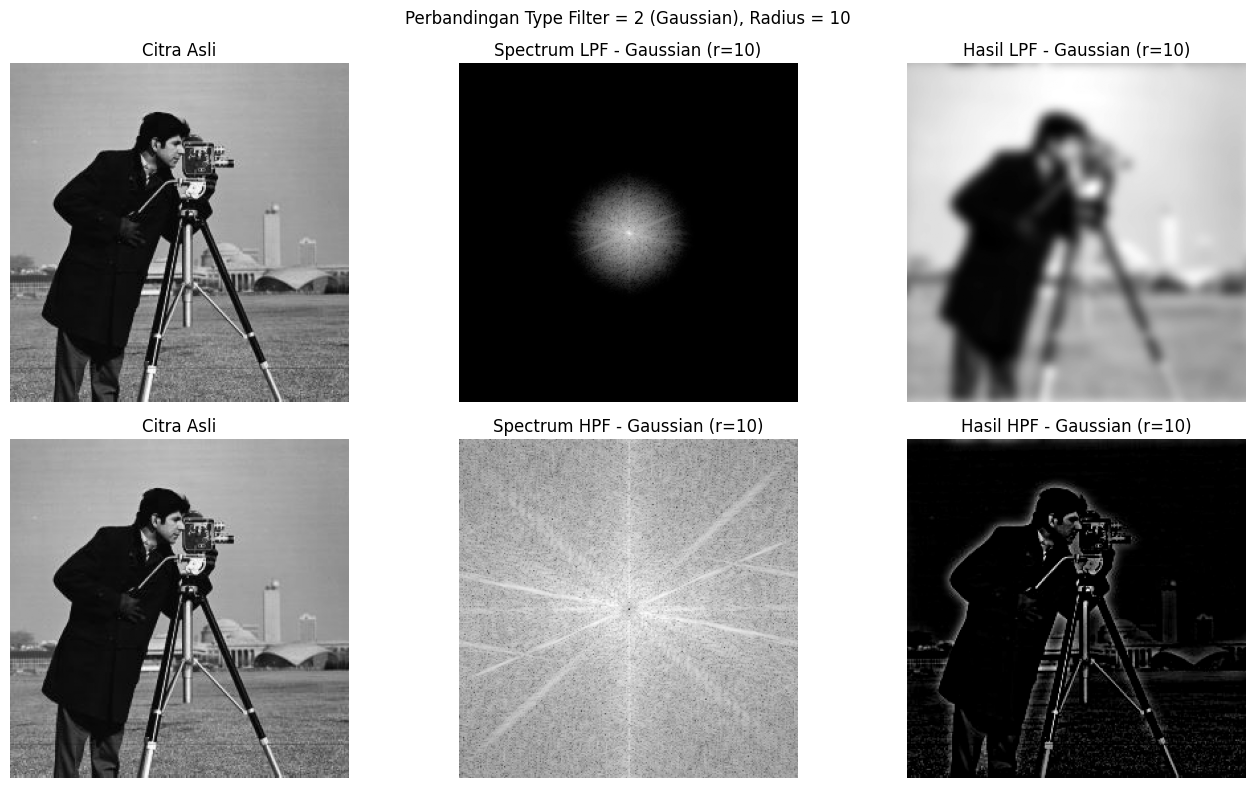

In [38]:
output_dir = "./assets"
os.makedirs(output_dir, exist_ok=True)

radius_tetap = 10
tipe_filter = [0, 1, 2]
label_tipe = {0: "Ideal", 1: "Butterworth", 2: "Gaussian"}

for t in tipe_filter:
    # Low-pass
    lowPassFilter = createLPFilter(image_fft.shape, maxLoc, radius_tetap, t)
    img_lp_filter = lowPassFilter * image_fft
    _, spektrum_lp = graySpectrum(img_lp_filter)

    img_ift_lp = cv2.dft(
        img_lp_filter,
        flags=cv2.DFT_INVERSE + cv2.DFT_REAL_OUTPUT + cv2.DFT_SCALE,
    )
    ori_lp = np.copy(img_ift_lp[:rows, :cols])

    for rr in range(rows):
        for cc in range(cols):
            if (rr + cc) % 2:
                ori_lp[rr][cc] = -1 * ori_lp[rr][cc]

    ori_lp = np.clip(ori_lp, 0, 255).astype(np.uint8)

    # High-pass
    highPassFilter = createHPFilter(image_fft.shape, maxLoc, radius_tetap, t)
    img_hp_filter = highPassFilter * image_fft
    _, spektrum_hp = graySpectrum(img_hp_filter)

    img_ift_hp = cv2.dft(
        img_hp_filter,
        flags=cv2.DFT_INVERSE + cv2.DFT_REAL_OUTPUT + cv2.DFT_SCALE,
    )
    ori_hp = np.copy(img_ift_hp[:rows, :cols])

    for rr in range(rows):
        for cc in range(cols):
            if (rr + cc) % 2:
                ori_hp[rr][cc] = -1 * ori_hp[rr][cc]

    ori_hp = np.clip(ori_hp, 0, 255).astype(np.uint8)

    # Tampilkan hasil
    fig, ax = plt.subplots(2, 3, figsize=(14, 8))

    ax[0, 0].imshow(img, cmap="gray")
    ax[0, 0].set_title("Citra Asli")
    ax[0, 0].axis("off")

    ax[0, 1].imshow(spektrum_lp, cmap="gray")
    ax[0, 1].set_title(f"Spectrum LPF - {label_tipe[t]} (r=10)")
    ax[0, 1].axis("off")

    ax[0, 2].imshow(ori_lp, cmap="gray")
    ax[0, 2].set_title(f"Hasil LPF - {label_tipe[t]} (r=10)")
    ax[0, 2].axis("off")

    ax[1, 0].imshow(img, cmap="gray")
    ax[1, 0].set_title("Citra Asli")
    ax[1, 0].axis("off")

    ax[1, 1].imshow(spektrum_hp, cmap="gray")
    ax[1, 1].set_title(f"Spectrum HPF - {label_tipe[t]} (r=10)")
    ax[1, 1].axis("off")

    ax[1, 2].imshow(ori_hp, cmap="gray")
    ax[1, 2].set_title(f"Hasil HPF - {label_tipe[t]} (r=10)")
    ax[1, 2].axis("off")

    plt.suptitle(f"Perbandingan Type Filter = {t} ({label_tipe[t]}), Radius = 10")
    plt.tight_layout()

    file_path = f"{output_dir}/type_{t}_radius_10_lpf_hpf.png"
    fig.savefig(file_path, dpi=200, bbox_inches="tight")
    print(f"Tersimpan: {file_path}")

    plt.show()
    plt.close(fig)